## ⭐ Star Coordinates (Star Plot / Star Coordinates Plot)

A multivariate visualization technique

🔹 What are Star Coordinates?

Star Coordinates map high-dimensional data into 2D space using linear combinations of axes.

Each dimension is represented as a vector (ray) from the origin.

Why Star Coordinates?

Used for:

High-dimensional visualization

Clustering intuition

Feature dominance analysis

Pattern discovery

Dimensionality reduction intuition

Alternative to PCA



### VARIATION 1 — Basic Star Coordinates (Manual Projection)

In [1]:
import numpy as np
import matplotlib.pyplot as plt


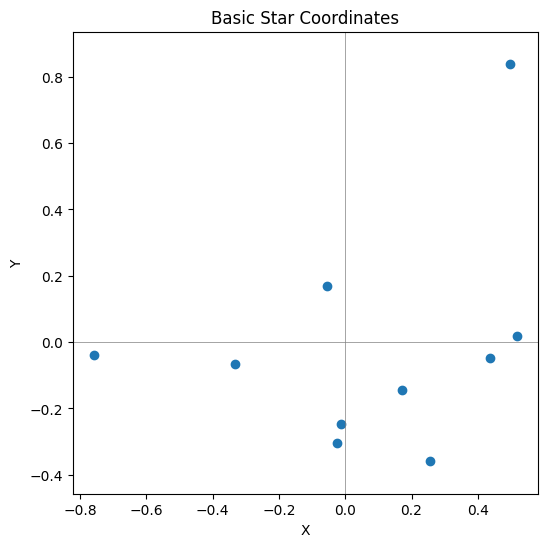

In [2]:
# Sample data: 10 points, 4 dimensions
np.random.seed(0)
data = np.random.rand(10, 4)

# Angles for each dimension
d = data.shape[1]
angles = np.linspace(0, 2*np.pi, d, endpoint=False)

# Projection
X = data @ np.cos(angles)
Y = data @ np.sin(angles)

plt.figure(figsize=(6, 6))
plt.scatter(X, Y)

plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)

plt.title("Basic Star Coordinates")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.show()


### VARIATION 2 — Add Feature Axes (Star Rays)

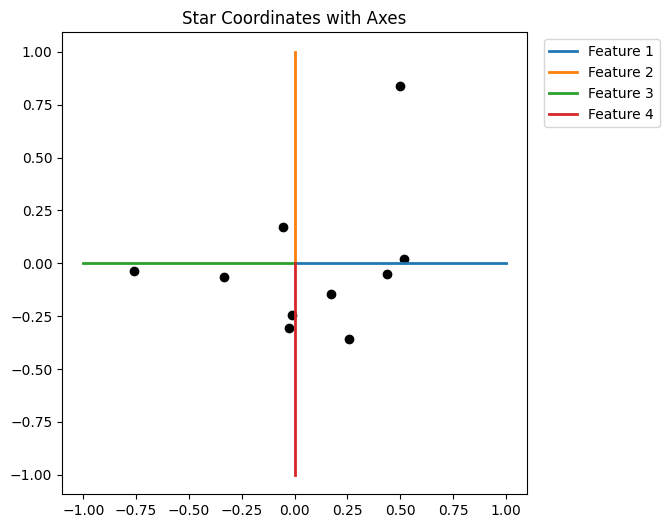

In [3]:
plt.figure(figsize=(6, 6))

# Draw axes
for i, angle in enumerate(angles):
    plt.plot(
        [0, np.cos(angle)],
        [0, np.sin(angle)],
        linewidth=2,
        label=f"Feature {i+1}"
    )

# Projected points
plt.scatter(X, Y, c="black")

plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.axis("equal")
plt.title("Star Coordinates with Axes")
plt.show()


### VARIATION 3 — Normalized Star Coordinates (Recommended)

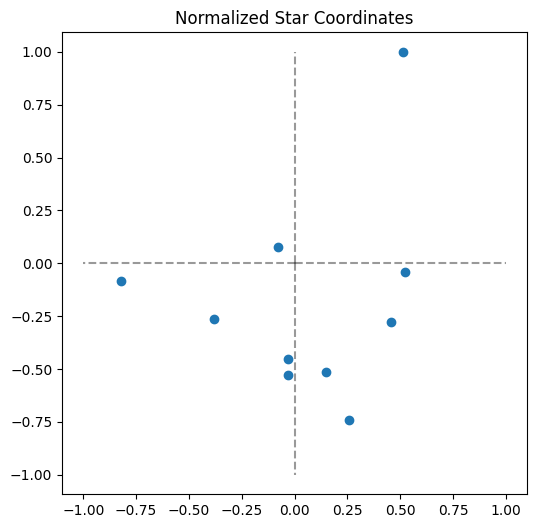

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_norm = scaler.fit_transform(data)

Xn = data_norm @ np.cos(angles)
Yn = data_norm @ np.sin(angles)

plt.figure(figsize=(6, 6))
plt.scatter(Xn, Yn, c="tab:blue")

for i, a in enumerate(angles):
    plt.plot([0, np.cos(a)], [0, np.sin(a)], 'k--', alpha=0.4)

plt.axis("equal")
plt.title("Normalized Star Coordinates")
plt.show()


### VARIATION 4 — Color Encoding (Class / Value)

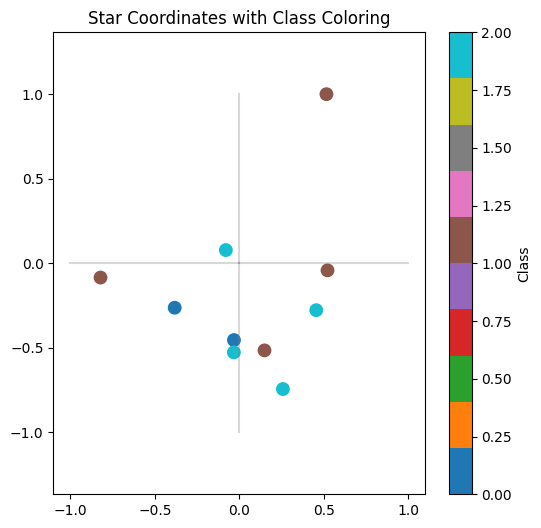

In [5]:
labels = np.random.randint(0, 3, size=len(data))

plt.figure(figsize=(6, 6))
plt.scatter(Xn, Yn, c=labels, cmap="tab10", s=80)

for a in angles:
    plt.plot([0, np.cos(a)], [0, np.sin(a)], color="gray", alpha=0.3)

plt.colorbar(label="Class")
plt.title("Star Coordinates with Class Coloring")
plt.axis("equal")
plt.show()


### VARIATION 5 — Star Coordinates with Feature Labels

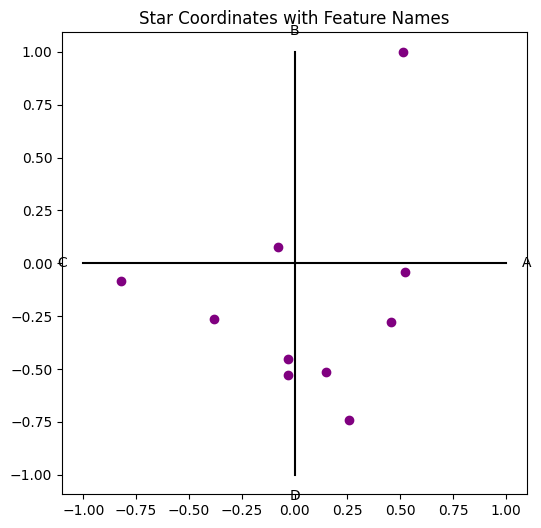

In [6]:
feature_names = ["A", "B", "C", "D"]

plt.figure(figsize=(6, 6))

for i, angle in enumerate(angles):
    x, y = np.cos(angle), np.sin(angle)
    plt.plot([0, x], [0, y], color="black")
    plt.text(1.1*x, 1.1*y, feature_names[i],
             ha="center", va="center", fontsize=10)

plt.scatter(Xn, Yn, c="purple")
plt.axis("equal")
plt.title("Star Coordinates with Feature Names")
plt.show()


### VARIATION 6 — Weighted Star Coordinates

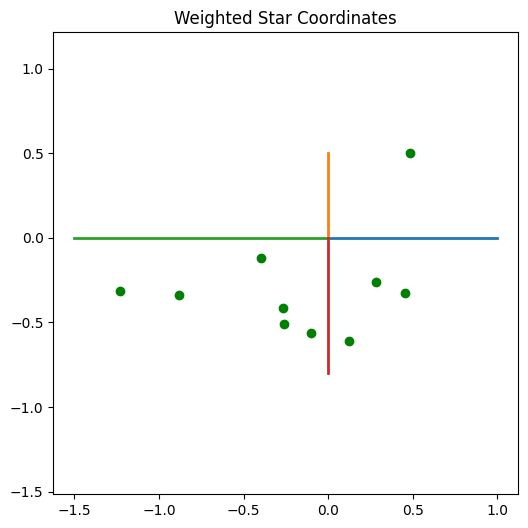

In [7]:
weights = np.array([1.0, 0.5, 1.5, 0.8])

Xw = data_norm @ (weights * np.cos(angles))
Yw = data_norm @ (weights * np.sin(angles))

plt.figure(figsize=(6, 6))
plt.scatter(Xw, Yw, c="green")

for i, a in enumerate(angles):
    plt.plot(
        [0, weights[i]*np.cos(a)],
        [0, weights[i]*np.sin(a)],
        linewidth=2
    )

plt.axis("equal")
plt.title("Weighted Star Coordinates")
plt.show()


### VARIATION 7 — Cluster Visualization with Star Coordinates

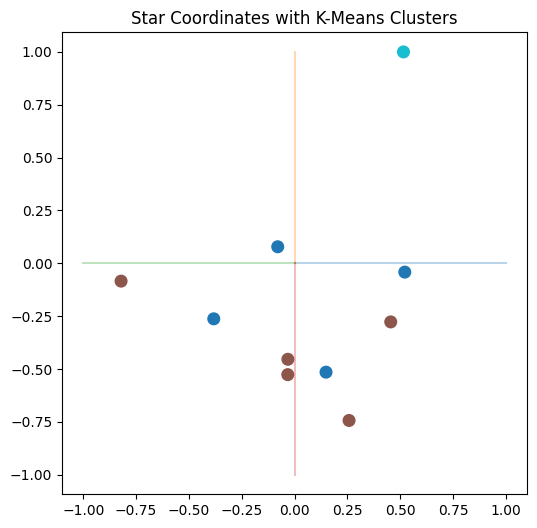

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(data_norm)

plt.figure(figsize=(6, 6))
plt.scatter(Xn, Yn, c=labels, cmap="tab10", s=70)

for a in angles:
    plt.plot([0, np.cos(a)], [0, np.sin(a)], alpha=0.3)

plt.title("Star Coordinates with K-Means Clusters")
plt.axis("equal")
plt.show()


### VARIATION 8 — Animated Star Coordinates (Time-Varying)

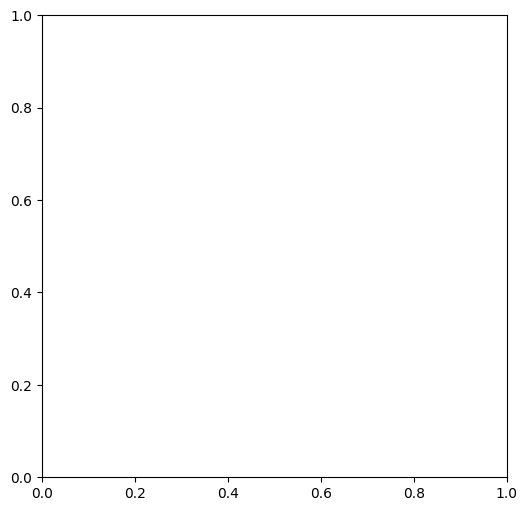

In [9]:
from matplotlib import animation

fig, ax = plt.subplots(figsize=(6, 6))

def update(frame):
    ax.clear()
    dynamic = data_norm * (0.5 + 0.5*np.sin(frame / 10))

    X = dynamic @ np.cos(angles)
    Y = dynamic @ np.sin(angles)

    ax.scatter(X, Y, c="blue")

    for a in angles:
        ax.plot([0, np.cos(a)], [0, np.sin(a)], alpha=0.3)

    ax.set_title(f"Star Coordinates (t = {frame})")
    ax.axis("equal")

ani = animation.FuncAnimation(fig, update, frames=60, interval=100)
plt.show()


### VARIATION 9 — Interactive Star Coordinates (Plotly)

In [10]:
import plotly.graph_objects as go

X = Xn
Y = Yn

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=X, y=Y,
    mode="markers",
    marker=dict(size=8),
))

for i, a in enumerate(angles):
    fig.add_trace(go.Scatter(
        x=[0, np.cos(a)],
        y=[0, np.sin(a)],
        mode="lines",
        name=f"Feature {i+1}"
    ))

fig.update_layout(
    title="Interactive Star Coordinates",
    xaxis=dict(scaleanchor="y"),
    yaxis=dict(scaleanchor="x"),
)

fig.show()


### VARIATION 10 — Star Coordinates vs PCA (Comparison)

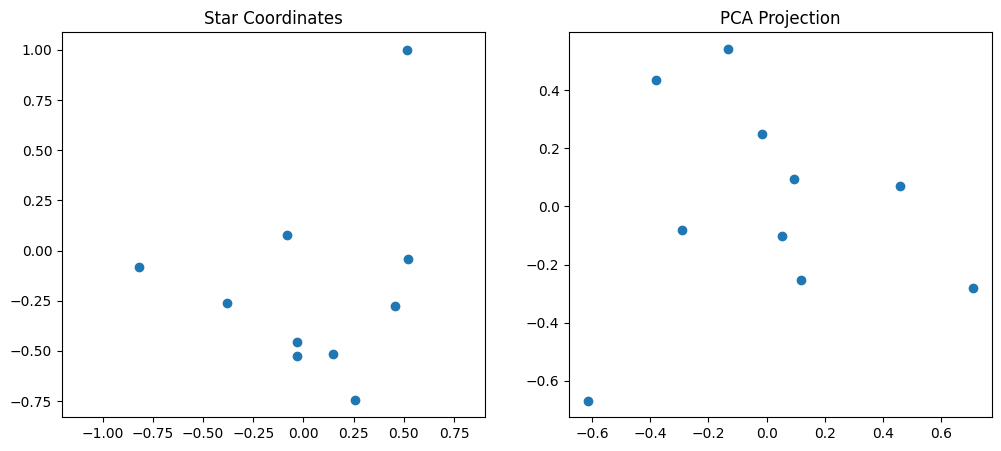

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
Xp = pca.fit_transform(data_norm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Star coordinates
axes[0].scatter(Xn, Yn)
axes[0].set_title("Star Coordinates")
axes[0].axis("equal")

# PCA
axes[1].scatter(Xp[:, 0], Xp[:, 1])
axes[1].set_title("PCA Projection")
axes[1].axis("equal")

plt.show()


### VARIATION 11 — High-Dimensional (8–12 Features)

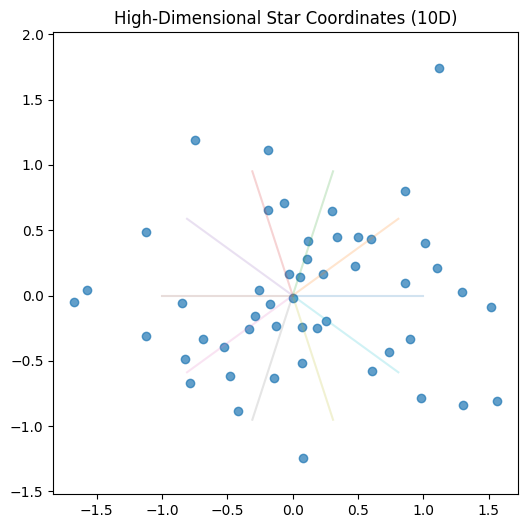

In [12]:
d = 10
data_hd = np.random.rand(50, d)
angles_hd = np.linspace(0, 2*np.pi, d, endpoint=False)

X = data_hd @ np.cos(angles_hd)
Y = data_hd @ np.sin(angles_hd)

plt.figure(figsize=(6, 6))
plt.scatter(X, Y, alpha=0.7)

for a in angles_hd:
    plt.plot([0, np.cos(a)], [0, np.sin(a)], alpha=0.2)

plt.title("High-Dimensional Star Coordinates (10D)")
plt.axis("equal")
plt.show()


### VARIATION 12 — Mathematical Visualization of Mapping

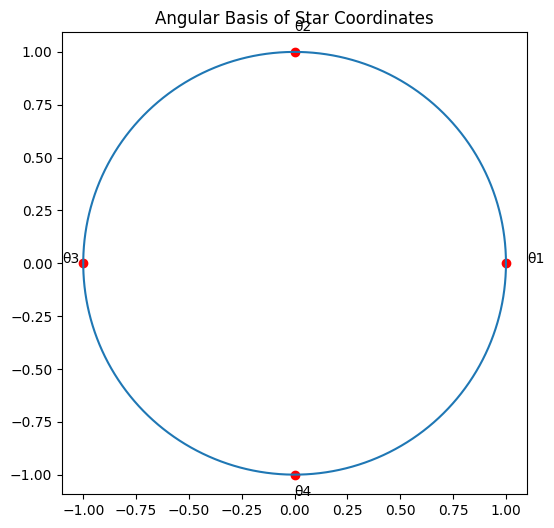

In [13]:
theta = np.linspace(0, 2*np.pi, 200)

plt.figure(figsize=(6, 6))
plt.plot(np.cos(theta), np.sin(theta))
plt.scatter(np.cos(angles), np.sin(angles), color="red")

for i, a in enumerate(angles):
    plt.text(np.cos(a)*1.1, np.sin(a)*1.1, f"θ{i+1}")

plt.title("Angular Basis of Star Coordinates")
plt.axis("equal")
plt.show()
